# E-Commerce Recommendation System — Model Training

This notebook implements and evaluates:
1. Content-Based Filtering (cosine similarity on product rating profiles)
2. User-Based Collaborative Filtering
3. Item-Based Collaborative Filtering
4. Matrix Factorization with SVD (via Surprise library)

Evaluation metrics: RMSE, MAE, Precision@K, Recall@K, NDCG@K

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD, KNNBasic, KNNWithMeans
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/ratings_filtered.csv')
print('Loaded filtered dataset:', df.shape)
df.head()

Loaded filtered dataset: (350229, 4)


,userId,productId,rating,timestamp
0,A274NIJWOQWE30,1304351475,5.0,1385251200
1,AN33X95J5460X,1304351475,4.0,1395187200
2,A1ZY0K46FYOTB6,1403790965,5.0,1357603200
3,A3MAATZ091QZGE,1403790965,5.0,1372550400
4,A3M7ROZKQW6F69,3227001381,4.0,1351814400


## 1. Content-Based Filtering

For each product, build a profile from average rating and number of ratings.
Recommend products similar to what the user has already rated highly.

In [2]:
# Build product feature matrix
product_features = df.groupby('productId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count'),
    rating_std=('rating', 'std')
).fillna(0).reset_index()

print('Product feature matrix shape:', product_features.shape)
product_features.head()

Product feature matrix shape: (34818, 4)


,productId,avg_rating,num_ratings,rating_std
0,1304351475,4.5,2,0.707107
1,1403790965,5.0,2,0.000000
2,3227001381,3.5,2,0.707107
3,535795531X,3.0,1,0.000000
4,5357955948,3.5,2,2.121320


In [3]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = ['avg_rating', 'num_ratings', 'rating_std']
scaler = MinMaxScaler()
product_features_scaled = scaler.fit_transform(product_features[feature_cols])

# Cosine similarity between all products
content_sim_matrix = cosine_similarity(product_features_scaled)
content_sim_df = pd.DataFrame(
    content_sim_matrix,
    index=product_features['productId'],
    columns=product_features['productId']
)
print('Similarity matrix shape:', content_sim_df.shape)

def get_content_recommendations(product_id, top_n=5):
    """Get top N similar products to a given product."""
    if product_id not in content_sim_df.index:
        return []
    sim_scores = content_sim_df[product_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(product_id)  # remove itself
    return list(sim_scores.head(top_n).index)

# Test it
sample_product = df['productId'].value_counts().index[0]
recs = get_content_recommendations(sample_product)
print(f'Content-Based Recommendations for product {sample_product}:')
for r in recs:
    print(' -', r)

Similarity matrix shape: (34818, 34818)
Content-Based Recommendations for product B000ZMBSPE:
 - B0043OYFKU
 - B0069FDR96
 - B004OHQR1Q
 - B000142FVW
 - B003V265QW


## 2. Collaborative Filtering — Sparse User-Item Matrix

**Fix:** The original `.pivot_table().fillna(0)` creates a massive dense matrix that causes a MemoryError.
We use a scipy sparse matrix instead — it only stores non-zero entries, using ~100x less RAM.

In [4]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# --- Encode user and product IDs to integer indices ---
user_ids    = df['userId'].astype('category')
product_ids = df['productId'].astype('category')

user_idx    = user_ids.cat.codes      # integer index per user
product_idx = product_ids.cat.codes   # integer index per product

user_list    = user_ids.cat.categories.tolist()    # maps index → userId
product_list = product_ids.cat.categories.tolist() # maps index → productId

# --- Build sparse CSR matrix (users x products) ---
# Only stores the ~100k non-zero ratings, NOT millions of zeros
sparse_matrix = csr_matrix(
    (df['rating'].values, (user_idx.values, product_idx.values)),
    shape=(len(user_list), len(product_list))
)

print(f'Sparse matrix shape : {sparse_matrix.shape}')
print(f'Non-zero entries    : {sparse_matrix.nnz:,}')
print(f'Memory (dense would): ~{sparse_matrix.shape[0] * sparse_matrix.shape[1] * 8 / 1e9:.2f} GB')
print(f'Memory (sparse uses): ~{sparse_matrix.data.nbytes / 1e6:.1f} MB')

Sparse matrix shape : (51888, 34818)
Non-zero entries    : 350,229
Memory (dense would): ~14.45 GB
Memory (sparse uses): ~2.8 MB


In [5]:
# --- User-User cosine similarity on sparse matrix ---
# cosine_similarity handles sparse input natively — no dense conversion
print('Computing user-user similarity (sparse)...')
user_sim_sparse = cosine_similarity(sparse_matrix, dense_output=False)
print('User similarity matrix shape:', user_sim_sparse.shape)

# Helper lookups
user_to_idx = {u: i for i, u in enumerate(user_list)}
idx_to_user = {i: u for i, u in enumerate(user_list)}
prod_to_idx = {p: i for i, p in enumerate(product_list)}
idx_to_prod = {i: p for i, p in enumerate(product_list)}

def get_user_recommendations(user_id, top_n=5, top_k_users=10):
    """Recommend products liked by similar users — fully sparse, memory-safe."""
    if user_id not in user_to_idx:
        return []

    uid = user_to_idx[user_id]

    # Get similarity scores for this user as a dense 1D array
    sim_row = np.asarray(user_sim_sparse[uid].todense()).flatten()
    sim_row[uid] = 0  # exclude self

    # Top K most similar user indices
    top_k_idx = np.argsort(sim_row)[::-1][:top_k_users]

    # Products already rated by this user
    rated_prod_idx = set(sparse_matrix[uid].nonzero()[1])

    # Aggregate ratings from similar users (sparse slice)
    similar_matrix = sparse_matrix[top_k_idx]          # shape: (top_k, n_products)
    agg_scores     = np.asarray(similar_matrix.mean(axis=0)).flatten()

    # Zero out already-rated products
    for idx in rated_prod_idx:
        agg_scores[idx] = 0

    # Top N unrated products
    top_prod_idx = np.argsort(agg_scores)[::-1][:top_n]
    return [idx_to_prod[i] for i in top_prod_idx if agg_scores[i] > 0]

sample_user = df['userId'].value_counts().index[0]
recs = get_user_recommendations(sample_user)
print(f'\nUser-Based Recs for user {str(sample_user)[:20]}...:')
for r in recs:
    print(' -', r)

Computing user-user similarity (sparse)...
User similarity matrix shape: (51888, 51888)

User-Based Recs for user A2V5R832QCSOMX...:
 - B004FUUMJK
 - B003USJW3A
 - B00GR4TPW2
 - B001E6TX0C
 - B001CN3QKK


## 3. Matrix Factorization — SVD via Surprise

In [6]:
# Prepare Surprise dataset
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userId', 'productId', 'rating']], reader)

# Train-test split (80-20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# --- SVD ---
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)
predictions_svd = svd.test(testset)

rmse_svd = accuracy.rmse(predictions_svd)
mae_svd  = accuracy.mae(predictions_svd)
print(f'SVD — RMSE: {rmse_svd:.4f} | MAE: {mae_svd:.4f}')

RMSE: 1.1218
MAE:  0.8659
SVD — RMSE: 1.1218 | MAE: 0.8659


In [9]:
# ---SVD++ based user ---#
from surprise import SVDpp

svdpp = SVDpp(n_factors=20, n_epochs=15, lr_all=0.005, reg_all=0.02, random_state=42)
svdpp.fit(trainset)
predictions_svdpp = svdpp.test(testset)

rmse_svdpp = accuracy.rmse(predictions_svdpp)
mae_svdpp  = accuracy.mae(predictions_svdpp)
print(f'SVD++ — RMSE: {rmse_svdpp:.4f} | MAE: {mae_svdpp:.4f}')

RMSE: 1.1218
MAE:  0.8714
SVD++ — RMSE: 1.1218 | MAE: 0.8714


In [10]:
# --- NMF ---
# Non-Negative Matrix Factorization: decomposes the ratings matrix into
# non-negative user and item latent factors. Memory-safe on any dataset size.
from surprise import NMF

nmf = NMF(n_factors=30, n_epochs=20, random_state=42)
nmf.fit(trainset)
predictions_nmf = nmf.test(testset)

rmse_nmf = accuracy.rmse(predictions_nmf)
mae_nmf  = accuracy.mae(predictions_nmf)
print(f'NMF — RMSE: {rmse_nmf:.4f} | MAE: {mae_nmf:.4f}')

RMSE: 1.3031
MAE:  0.7958
NMF — RMSE: 1.3031 | MAE: 0.7958


## 4. Model Comparison — RMSE & MAE

         RMSE     MAE
Model                
SVD    1.1218  0.8659
SVD++  1.1218  0.8714
NMF    1.3031  0.7958


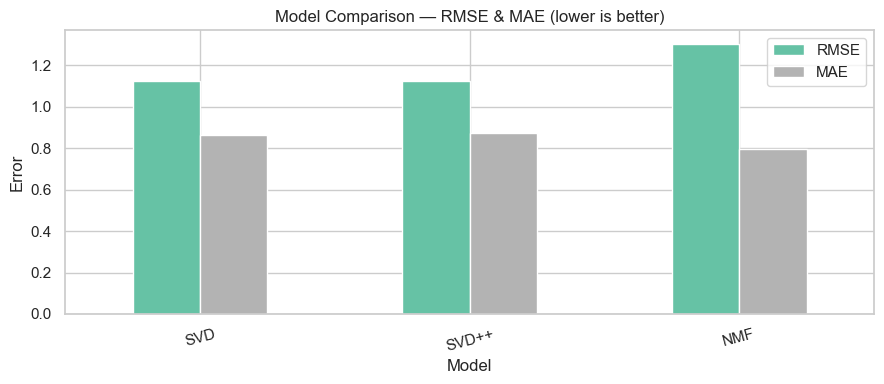

In [11]:
comparison = pd.DataFrame({
    'Model': ['SVD', 'SVD++', 'NMF'],
    'RMSE':  [rmse_svd, rmse_svdpp, rmse_nmf],
    'MAE':   [mae_svd,  mae_svdpp,  mae_nmf]
}).set_index('Model').round(4)

print(comparison)

comparison.plot(kind='bar', figsize=(9, 4), colormap='Set2', edgecolor='white')
plt.title('Model Comparison — RMSE & MAE (lower is better)')
plt.ylabel('Error')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Precision@K, Recall@K, NDCG@K — SVD

In [12]:
from collections import defaultdict

def precision_recall_ndcg_at_k(predictions, k=10, threshold=4.0):
    """Compute Precision@K, Recall@K, and NDCG@K."""
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls, ndcgs = [], [], []

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel       = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k     = sum(1 for (est, _)    in top_k)
        n_rel_rec_k = sum(1 for (est, true_r) in top_k if true_r >= threshold)

        prec = n_rel_rec_k / n_rec_k    if n_rec_k    > 0 else 0
        rec  = n_rel_rec_k / n_rel      if n_rel      > 0 else 0
        precisions.append(prec)
        recalls.append(rec)

        # NDCG
        dcg  = sum((1 if true_r >= threshold else 0) / np.log2(i + 2)
                   for i, (_, true_r) in enumerate(top_k))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(n_rel, k)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

for k in [5, 10, 20]:
    p, r, n = precision_recall_ndcg_at_k(predictions_svd, k=k, threshold=4.0)
    print(f'K={k:2d} | Precision@K={p:.4f} | Recall@K={r:.4f} | NDCG@K={n:.4f}')

K= 5 | Precision@K=0.7806 | Recall@K=0.8540 | NDCG@K=0.8360
K=10 | Precision@K=0.7794 | Recall@K=0.8622 | NDCG@K=0.8377
K=20 | Precision@K=0.7792 | Recall@K=0.8635 | NDCG@K=0.8379


## 6. SVD — Get Recommendations for a User

In [13]:
def get_svd_recommendations(user_id, svd_model, df, top_n=10):
    """Get top N product recommendations for a user using SVD."""
    all_products  = df['productId'].unique()
    rated_products = df[df['userId'] == user_id]['productId'].unique()
    unrated = [p for p in all_products if p not in rated_products]

    predictions = [(p, svd_model.predict(user_id, p).est) for p in unrated]
    predictions.sort(key=lambda x: x[1], reverse=True)

    return pd.DataFrame(predictions[:top_n], columns=['productId', 'predicted_rating'])

# Retrain on full dataset for best performance
full_trainset = data.build_full_trainset()
svd_final = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_final.fit(full_trainset)

sample_user = df['userId'].value_counts().index[0]
recs_df = get_svd_recommendations(sample_user, svd_final, df, top_n=10)
print(f'Top 10 SVD Recommendations for user {sample_user[:20]}...')
print(recs_df.to_string(index=False))

Top 10 SVD Recommendations for user A2V5R832QCSOMX...
 productId  predicted_rating
B000052ZSS                 5
B00005V5P6                 5
B00008J2XQ                 5
B0000C0XL8                 5
B00027EG9C                 5
B0002CTSRM                 5
B0002FCD5I                 5
B0002JGU30                 5
B00062ADJA                 5
B0006HCE60                 5


## 7. Save Models

In [14]:
import scipy.sparse as sp

os.makedirs('../app', exist_ok=True)

# SVD model
joblib.dump(svd_final, '../app/svd_model.pkl')

# Sparse matrix + index mappings (replaces old dense user_item_matrix)
sp.save_npz('../app/sparse_matrix.npz', sparse_matrix)
joblib.dump({'user_to_idx': user_to_idx, 'idx_to_user': idx_to_user,
             'prod_to_idx': prod_to_idx, 'idx_to_prod': idx_to_prod},
            '../app/index_maps.pkl')

# Content-based + product features
joblib.dump(content_sim_df,   '../app/content_sim_matrix.pkl')
joblib.dump(product_features, '../app/product_features.pkl')

# Clean ratings CSV for the Streamlit app
df.to_csv('../app/ratings_clean.csv', index=False)

print('All models and data saved to ../app/')

All models and data saved to ../app/
